# [STARE] MATHFI -- SPLIT TESTS #3 -- LOO AGG FOLD LOOPS -- seed 1337

In [40]:
import sys, os
sys.path.append(os.path.abspath('../../'))

print( os.getcwd())
sys.path


c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\notebooks\train_all


['C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\DLLs',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\lib',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv310',
 '',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv310\\lib\\site-packages',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Fe

In [41]:
from src.models.unet import UNet
print(UNet)

<class 'src.models.unet.UNet'>


In [42]:
from pathlib import Path
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# CHANGE THESE

In [43]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 1337
DATASET = "STARE" # "DRIVE" | "STARE" | "CHASEDB1"

PATCH_SIZE = 128
VAL_WINDOW  = PATCH_SIZE
VAL_OVERLAP = 0.25

VESSEL_BIAS=0.7
MIN_PERCENT_VESSEL=0.008
V_MULT=30
DENSE_BIAS=None
BATCH_SIZE=2

IMG_SIZE=512

EPOCHS = 50
warmup_epochs = 5

FOLDS = 20
FOLD_ID = 1

THRESHOLD_EVAL = 0.5


MODEL_NAME = "MATHFI"
TITLE     = f"[{DATASET}] {MODEL_NAME} NEW SPLIT ({FOLDS} total folds) -- epochs={EPOCHS}"
SAVE_ROOT = Path(f"../../../../pth/{MODEL_NAME}_{DATASET}_NEWSPLIT")     # a clean experiment folder
SAVE_CKPT = SAVE_ROOT / "checkpoints"
SAVE_PRED = SAVE_ROOT / "predictions"   # per-image logits/prob/masks
SAVE_VIZ  = SAVE_ROOT / "visuals"       # PNG overlays per test image
SAVE_LOGS = SAVE_ROOT / "logs"
for d in [SAVE_ROOT, SAVE_CKPT, SAVE_PRED, SAVE_VIZ, SAVE_LOGS]: d.mkdir(parents=True, exist_ok=True)

DATASET_ROOT        = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"
DATASET_LABELFOLDER = "1st_manual"




# IMPORTS

In [44]:
import os, json, math, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt

# --- data utils ---
from src.data.splits import (
    split_drive_20_20,
    split_chase_subjectwise_20_8,
    split_stare_leave_one_out,
    stare_loo_fold,

    drive_random_20_20,

    chase_random_subject_split,

)

from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

# use YOUR metrics utilities
from src.training.metrics import (
    confusion_counts,
    dice as dice_metric,
    iou as iou_metric,
    roc_auc as roc_auc_metric,
    pr_auc as pr_auc_metric,
    acc_from_counts,
    recall_from_counts,          # sensitivity
    specificity_from_counts,     # specificity
    cldice
)

from src.training.train_cv import (
    sliding_window_forward_logits,
    update_dataset,
    train_one_epoch,
    validate_loss_only,
    atomic_torch_save,
    saveTrainVal
)



# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

In [45]:
def eval_leftout_with_fov(prob_1chw, gt_1chw, fov_1chw, thr=0.5):
    p = prob_1chw.squeeze().detach().cpu().numpy()       # [H,W], float
    g = gt_1chw.squeeze().detach().cpu().numpy()         # [H,W], {0,1}
    f = (fov_1chw.squeeze().detach().cpu().numpy() > 0.5)  # [H,W], bool

    if f.sum() == 0:
        return dict(ACC=float("nan"), Dice=float("nan"), IoU=float("nan"),
                    SEN=float("nan"), SPE=float("nan"), AUC=float("nan"),
                    AP=float("nan"), CLDICE=float("nan"),
                    tp=0, fp=0, tn=0, fn=0)

    # ---- 1-D path (strictly in-FOV) ----
    p_vec   = p[f]
    g_vec   = (g > 0.5)[f]
    pred_vec = (p_vec >= thr).astype(np.uint8)

    tp, fp, tn, fn = confusion_counts(pred_vec, g_vec)
    ACC  = float(acc_from_counts(tp, fp, tn, fn))
    SEN  = float(recall_from_counts(tp, fn))
    SPE  = float(specificity_from_counts(tn, fp))
    DICE = float(dice_metric(pred_vec, g_vec))
    IOU  = float(iou_metric(pred_vec, g_vec))
    try:    AUC = float(roc_auc_metric(p_vec, g_vec))
    except: AUC = float("nan")
    try:    AP  = float(pr_auc_metric(p_vec, g_vec))
    except: AP  = float("nan")

    # ---- 2-D path for clDice (mask by FOV but keep shape) ----
    pred_2d = ((p >= thr).astype(np.uint8)) * f.astype(np.uint8)
    g_2d    = ((g > 0.5).astype(np.uint8)) * f.astype(np.uint8)
    try:    CLDICE = float(cldice(pred_2d, g_2d))
    except: CLDICE = float("nan")

    return dict(ACC=ACC, Dice=DICE, IoU=IOU, SEN=SEN, SPE=SPE, AUC=AUC, AP=AP,
                CLDICE=CLDICE, tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))



# helpers and config

In [46]:
os.getcwd()

'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\notebooks\\train_all'

In [47]:
# --- model factory (fresh per fold) ---
from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet
BASE_KW = {"cbam_reduction": 16}

def make_model(MODEL_NAME, train_loader = None) -> nn.Module:
    if MODEL_NAME == "MATHFI":
        # --- loss ---
        from src.training.loss_functions import DiceBCEComplementLoss
        if train_loader is not None:
            def estimate_class_weights(loader, max_batches=20):
                with torch.no_grad():
                    s = 0.0; n = 0
                    for i, b in enumerate(loader):
                        s += b["mask"].float().mean().item(); n += 1
                        if i+1 >= max_batches: break
                p = max(1e-6, min(1-1e-6, s / max(1, n)))
                w1 = 1.0 / p; w0 = 1.0 / (1.0 - p)
                s2 = w0 + w1; w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
                return w0, w1
            
            w0, w1 = estimate_class_weights(train_loader, max_batches=20)
            loss_fn = DiceBCEComplementLoss(w0=w0, w1=w1, dice_weight=0.5, bce_weight=0.5,
                                            exact_equation=False, reduction="mean")
        else: loss_fn = None
        # --- model ---
        return DPCNConcatUNet(
            in_ch=1, enh_channels=64, iters=6,
            threshold_mode="scaled_vat", half_life=2.0,
            reduce_to=64, base_kwargs=BASE_KW
        ).to(DEVICE), loss_fn

    elif MODEL_NAME == "FR-UNet":
        loss_fn = nn.BCEWithLogitsLoss()
        from models.fr_unet import FR_UNet
        return FR_UNet().to(DEVICE), loss_fn
        
@torch.no_grad()
def sliding_window_forward_logits(model, img_1chw, window, overlap, device="cuda"):
    """
    img_1chw: torch.Tensor [1,1,H,W] on *any* device.
    Returns: averaged logits [1,1,H,W] on 'device'
    """
    model.eval()
    img = img_1chw.to(device, non_blocking=True)
    _, _, H, W = img.shape
    step = max(1, int(window * (1 - overlap)))

    # we'll average *logits* to keep your loss_fn (e.g., BCEWithLogits) unchanged
    acc  = torch.zeros_like(img, device=device)
    norm = torch.zeros_like(img, device=device)

    for y0 in range(0, max(1, H - window + 1), step):
        for x0 in range(0, max(1, W - window + 1), step):
            y1 = min(y0 + window, H); x1 = min(x0 + window, W)
            y0 = y1 - window;         x0 = x1 - window
            tile = img[:, :, y0:y1, x0:x1]                     # [1,1,win,win]
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                logit = model(tile)                            # [1,1,win,win]
            acc[:, :, y0:y1, x0:x1] += logit
            norm[:, :, y0:y1, x0:x1] += 1.0

    logits = acc / torch.clamp_min(norm, 1.0)
    return logits

def add_metrics(model_name, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics, test_loader_mathfi = None):
        

        model, _ = make_model(model_name, test_loader_mathfi)
        stem = Path(ckpt_path).stem  # "STARE_fold00"
        fold_id = int(stem.split("fold")[-1])  # 0
        #print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")

        _, te_pairs = stare_loo_fold(root, label_folder=label_folder, fold_id=fold_id)
        
        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=1, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        batch = next(iter(test_loader))
        x   = batch["image"].to(DEVICE)
        y   = batch["mask"].to(DEVICE)
        fov = batch.get("fov", torch.ones_like(y)).to(DEVICE)
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem

        logits = sliding_window_forward_logits(model, x, window=VAL_WINDOW, overlap=VAL_OVERLAP, device=DEVICE)
        prob   = torch.sigmoid(logits)
        # binm   = (prob >= threshold_eval).float()

        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = evaluate_and_print(model, test_loader, THRESHOLD_EVAL)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)

        def _fmt(v):  # pretty-print, handles NaN
            try:
                return f"{v:.4f}" if v == v else "nan"
            except Exception:
                return str(v)

        print(
            f"== [F{fold_id:02d}] {img_stem} == \n"
            + "\n".join([f"{k}={_fmt(m[k])}" for k in ["SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC"]])
        )


# MAIN RUN

In [48]:
# --- main LOO run ---
def run_stare_loo_experiment(
    model_name,
    root, 
    label_folder, 
    dataset,
    epochs, 
    warmup, 
    V_MULT,
    batch_size, 
    img_size, 
    patch_train, 
    patch_size, 
    vessel_bias_p,
    threshold_eval, 
    folds, 
    fold_id, 
    chckpnt_paths=None,
    SEED=1337,
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu",
):  
    rng = np.random.RandomState(SEED)
    all_metrics = []
    per_image_preds = {}   # img_stem -> dict(prob_path, bin_path, fold_id)
    
    while fold_id < folds:
        
        # add checkpoint paths to metric list
        if chckpnt_paths:
            for ckpt in chckpnt_paths:
                add_metrics(model_name, 
                            root, 
                            label_folder,
                            img_size, ckpt, 
                            threshold_eval, all_metrics) 
            chckpnt_paths.clear()

        print(f"\n========== {MODEL_NAME} {DATASET} NEW SPLIT, Fold {fold_id+1}/{folds} ==========")

        # 1) split
        tr_pairs, te_pairs = stare_loo_fold(root, label_folder=label_folder, fold_id=fold_id)
        # 2) carve val deterministically from the 19 train images (e.g., last 3)
        val_pairs = tr_pairs[-3:]
        tr_pairs_ = tr_pairs[:-3]

        # 3) loaders
        train_loader, val_loader = make_loaders(
            train_pairs=tr_pairs_, val_pairs=val_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=2,
            seed=SEED + fold_id, strict_fov=True,
            augs_train=get_train_augs(img_size),
            augs_val=get_val_augs(img_size),
            patch_train=patch_train, patch_size=patch_size,
            vessel_bias_p=vessel_bias_p, virtual_mult=V_MULT,
        )
        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=2,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
            patch_train=False
        )

        ###########################
        #  4) model & optimizer
        model, loss_fn = make_model(MODEL_NAME, train_loader)
             
        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))
        def lr_lambda(e):
            if e < warmup: return (e+1)/max(1, warmup)
            progress = (e - warmup) / max(1, epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        scheduler = LambdaLR(optimizer, lr_lambda)


        #######################
        #  5) train with best-val checkpointing
        best_val = float("inf")
        ckpt_path = SAVE_CKPT / f"{DATASET}_fold{fold_id:02d}.pth"

        train_losses, val_losses = [], []

        for ep in range(1, epochs+1):
            update_dataset(train_loader.dataset, ep)
            t0=time.time()
            tr_loss  = train_one_epoch(model, train_loader, optimizer, scaler, loss_fn, DEVICE)
            val_loss = validate_loss_only(model, val_loader, loss_fn, patch_size, VAL_OVERLAP, DEVICE)
            scheduler.step()
            print(f"[F{fold_id:02d} E{ep:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
                  f"lr={optimizer.param_groups[0]['lr']:.2e} time={(time.time()-t0):.1f}s")
            
            
            train_losses.append(float(tr_loss))
            val_losses.append(float(val_loss))

            if val_loss < best_val:
                best_val = val_loss
                atomic_torch_save(model.state_dict(), ckpt_path)
                print(f"\tCHECKPOINT SAVED: {ckpt_path}")
        
        ########################
        # 5a) save train loss vs val loss graph
        save_path = SAVE_VIZ / f"TrainVsVal__fold{fold_id:02d}.png"
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)

        epochs_val = np.arange(1, len(train_losses) + 1)
        saveTrainVal(epochs_val, fold_id, train_losses, val_losses, save_path, TITLE)

        ####################
        #  6) eval on left-out image using best checkpoint
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        
        ####################
        #  6a) metrics + print
        m = evaluate_and_print(model, test_loader, device = DEVICE, threshold=threshold_eval, compute_auc=True)
        m["fold_id"]  = fold_id
        batch = next(iter(test_loader))
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem
        m["image_id"] = img_stem
        all_metrics.append(m)
        
        ###################
        # 6b) visualization
        save_viz_dir = SAVE_VIZ / f"testSet__fold{fold_id:02d}.png"
        visualize_samples(
            model=model,
            dataloader=test_loader,
            n_rows=1,
            device=DEVICE,
            threshold=0.5,
            clamp_pred_with_fov=True,
            figsize_per_row=(12, 3),
            is_save = True,
            save_dir = save_viz_dir
        )
        print(f"\t== Visualization SAVED TO FILE: {save_viz_dir} ==")



        fold_id = fold_id + 1

        # END OF FOLD LOOP


    # 7) aggregate & save CSV
    import csv
    keys = ["fold_id","image_id","SEN","SPE", "CLDICE", "ACC","Dice","IoU","AUC","AP"]
    csv_path = SAVE_LOGS / f"{DATASET}_newSplit_perfold.csv"
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for row in all_metrics: w.writerow({k: row.get(k, "") for k in keys})

    # mean±std
    def _ms(name):
        arr = np.array([r[name] for r in all_metrics if not np.isnan(r[name])], dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    summary = {k: _ms(k) for k in ["SEN","SPE","CLDICE","ACC","Dice","IoU","AUC","AP"]}
    print(f"\n=== {MODEL_NAME} {DATASET} NEW SPLITS ({FOLDS} folds) — mean ± std ===")
    for k,(mu,sig) in summary.items():
        print(f"{k}: {mu:.4f} ± {sig:.4f}")

    with open(SAVE_LOGS / f"{DATASET}_newSplit_summary.json","w") as f:
        json.dump({k: {"mean": mu, "std": sig} for k,(mu,sig) in summary.items()}, f, indent=2)

    # 8) (optional) gallery index of unbiased predictions
    with open(SAVE_LOGS / f"{DATASET}_newSplit_per_image_preds.json","w") as f:
        json.dump(per_image_preds, f, indent=2)

    return all_metrics, summary


In [49]:
# Check indiv chkpoint paths scores
"""
check_checkpoints = [
 f"..\..\..\..\pth\{MODEL_NAME}_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
]
stem = Path(check_checkpoints[0]).stem  # "STARE_fold00"
fold_id = int(stem.split("fold")[-1])  # 0

if MODEL_NAME == "MATHFI":
    _, te_pairs_mathfi = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=FOLD_ID)

    _, test_loader_mathfi = make_loaders(
        train_pairs=te_pairs_mathfi, val_pairs=te_pairs_mathfi,
        image_size=IMG_SIZE, batch_size=1, num_workers=1,
        seed=SEED, strict_fov=True,
        augs_train=None, augs_val=get_val_augs(IMG_SIZE),
    )
else: test_loader_mathfi=None

for checkpoint in check_checkpoints:
    add_metrics(MODEL_NAME,
                DATASET_ROOT, 
                DATASET_LABELFOLDER,
                IMG_SIZE, 
                checkpoint,
                THRESHOLD_EVAL, []
                , test_loader_mathfi=test_loader_mathfi)

"""


'\ncheck_checkpoints = [\n f"..\\..\\..\\..\\pth\\{MODEL_NAME}_STARE_NEWSPLIT\\checkpoints\\STARE_fold00.pth",\n]\nstem = Path(check_checkpoints[0]).stem  # "STARE_fold00"\nfold_id = int(stem.split("fold")[-1])  # 0\n\nif MODEL_NAME == "MATHFI":\n    _, te_pairs_mathfi = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=FOLD_ID)\n\n    _, test_loader_mathfi = make_loaders(\n        train_pairs=te_pairs_mathfi, val_pairs=te_pairs_mathfi,\n        image_size=IMG_SIZE, batch_size=1, num_workers=1,\n        seed=SEED, strict_fov=True,\n        augs_train=None, augs_val=get_val_augs(IMG_SIZE),\n    )\nelse: test_loader_mathfi=None\n\nfor checkpoint in check_checkpoints:\n    add_metrics(MODEL_NAME,\n                DATASET_ROOT, \n                DATASET_LABELFOLDER,\n                IMG_SIZE, \n                checkpoint,\n                THRESHOLD_EVAL, []\n                , test_loader_mathfi=test_loader_mathfi)\n\n'

In [50]:
"""
path = r"..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\predictions\01_test__fold00.pt"
data = torch.load(path, map_location="cpu")

stem = Path(path).stem  # "STARE_fold00"
fold_id = int(stem.split("fold")[-1])  # 0

_, te_pairs = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=fold_id)

_, test_loader = make_loaders(
    train_pairs=te_pairs, val_pairs=te_pairs,
    image_size=IMG_SIZE, batch_size=1, num_workers=1,
    seed=SEED, strict_fov=True,
    augs_train=None, augs_val=get_val_augs(IMG_SIZE),
)

batch = next(iter(test_loader))
x   = batch["image"].to(DEVICE)
y   = batch["mask"].to(DEVICE)
logits = data["logits"]   # raw model outputs before sigmoid
prob   = data["prob"]     # probability map (0–1)
binm   = data["bin"]      # binary mask (0 or 1)
img_path = data["image_path"]
fold_id = data["fold"]
img_stem = Path(batch["image_path"][0]).stem

fig, axs = plt.subplots(1,4, figsize=(12,3))
axs[0].imshow(x[0,0].cpu(), cmap="gray"); axs[0].set_title("Image"); axs[0].axis("off")
axs[1].imshow(y[0,0].cpu(), cmap="gray"); axs[1].set_title("GT");    axs[1].axis("off")
axs[2].imshow(prob[0,0].cpu(), cmap="gray"); axs[2].set_title("Prob"); axs[2].axis("off")
axs[3].imshow(binm[0,0].cpu(), cmap="gray"); axs[3].set_title(f"Pred@0.5"); axs[3].axis("off")
fig.suptitle(f"{DATASET} NEW SPLITS Fold {fold_id} — {img_stem}")
plt.tight_layout(); plt.show()
"""


'\npath = r"..\\..\\..\\..\\pth\\MATHFI_STARE_NEWSPLIT\\predictions\x01_test__fold00.pt"\ndata = torch.load(path, map_location="cpu")\n\nstem = Path(path).stem  # "STARE_fold00"\nfold_id = int(stem.split("fold")[-1])  # 0\n\n_, te_pairs = stare_loo_fold(DATASET_ROOT, label_folder=DATASET_LABELFOLDER, fold_id=fold_id)\n\n_, test_loader = make_loaders(\n    train_pairs=te_pairs, val_pairs=te_pairs,\n    image_size=IMG_SIZE, batch_size=1, num_workers=1,\n    seed=SEED, strict_fov=True,\n    augs_train=None, augs_val=get_val_augs(IMG_SIZE),\n)\n\nbatch = next(iter(test_loader))\nx   = batch["image"].to(DEVICE)\ny   = batch["mask"].to(DEVICE)\nlogits = data["logits"]   # raw model outputs before sigmoid\nprob   = data["prob"]     # probability map (0–1)\nbinm   = data["bin"]      # binary mask (0 or 1)\nimg_path = data["image_path"]\nfold_id = data["fold"]\nimg_stem = Path(batch["image_path"][0]).stem\n\nfig, axs = plt.subplots(1,4, figsize=(12,3))\naxs[0].imshow(x[0,0].cpu(), cmap="gray");

In [51]:
"""
from src.data.splits import chase_mc_balanced_splits


check_checkpoints = [
 r"..\..\..\..\pth\MATHFI_CHASEDB1_NEWSPLIT\checkpoints\CHASEDB1_fold00.pth",
]


root = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"


splits, counts = chase_mc_balanced_splits(root, label_folder=DATASET_LABELFOLDER, n_runs=20)


def add_metrics(model_name, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics, test_loader_mathfi = None):
        
        model, _ = make_model(model_name, test_loader_mathfi)
        stem = Path(ckpt_path).stem  # "STARE_fold00"
        fold_id = int(stem.split("fold")[-1])  # 0
        #print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")

        _, te_pairs, _ = splits[fold_id]


        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=IMG_SIZE, batch_size=1, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(IMG_SIZE),
        )
        
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        
        img_stem = f"fold{fold_id:02d}_testset"
        print(
            f"\n== [F{fold_id:02d}] {img_stem} == \n")

        m = evaluate_and_print(model, test_loader, 
                               device = DEVICE, threshold=threshold_eval, compute_auc=True)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)  

##########################
# 2) split dataset
_, te_pairs, _ = splits[0]

_, test_loader = make_loaders(
train_pairs=te_pairs, val_pairs=te_pairs,
image_size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=2,
seed=SEED, strict_fov=True,
augs_train=None, augs_val=get_val_augs(IMG_SIZE),
patch_train=False
)

for checkpoint in check_checkpoints:
    add_metrics(MODEL_NAME, 
                root, 
                DATASET_LABELFOLDER,
                IMG_SIZE, 
                checkpoint,
                THRESHOLD_EVAL, [], test_loader)


"""

'\nfrom src.data.splits import chase_mc_balanced_splits\n\n\ncheck_checkpoints = [\n r"..\\..\\..\\..\\pth\\MATHFI_CHASEDB1_NEWSPLIT\\checkpoints\\CHASEDB1_fold00.pth",\n]\n\n\nroot = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"\n\n\nsplits, counts = chase_mc_balanced_splits(root, label_folder=DATASET_LABELFOLDER, n_runs=20)\n\n\ndef add_metrics(model_name, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics, test_loader_mathfi = None):\n        \n        model, _ = make_model(model_name, test_loader_mathfi)\n        stem = Path(ckpt_path).stem  # "STARE_fold00"\n        fold_id = int(stem.split("fold")[-1])  # 0\n        #print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")\n\n        _, te_pairs, _ = splits[fold_id]\n\n\n        _, test_loader = make_loaders(\n            train_pairs=te_pairs, val_pairs=te_pairs,\n            image_size=IMG_SIZE, batch_size=1, num_workers=1,\n            seed=SEED, strict_fov=True,\n            augs_train=None,

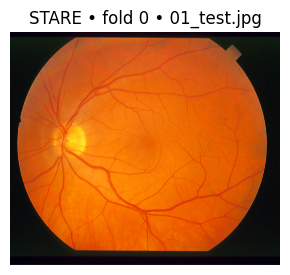

=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8358
Specificity    : 0.9784
clDice         : 0.7665
Accuracy       : 0.9697
Dice           : 0.7717
IoU            : 0.6283
Precision      : 0.7168
FPR            : 0.0216
FDR            : 0.2832
Dice_thin      : 0.4867
Dice_thick     : 0.5902
ROC_AUC        : 0.9878
PR_AUC         : 0.8640
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8358
Specificity    : 0.9784
F1/Dice        : 0.7717
Accuracy       : 0.9697
IoU            : 0.6283
Precision      : 0.7168
FPR            : 0.0216
FDR            : 0.2832
ROC_AUC        : 0.9878
PR_AUC         : 0.8640
== [F00] 01_test == 
SEN=0.8358
SPE=0.9784
CLDICE=0.7665
ACC=0.9697
Dice=0.7717
IoU=0.6283
AUC=0.9878

========== MATHFI STARE NEW SPLIT, Fold 2/20 ==========


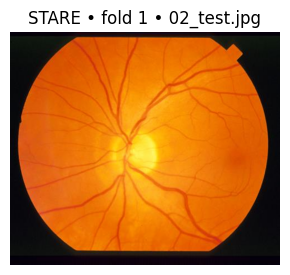

[F01 E001] train=1.0098 val=0.9488 lr=1.20e-04 time=28.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E002] train=0.7518 val=0.6831 lr=1.80e-04 time=27.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E003] train=0.6088 val=0.5344 lr=2.40e-04 time=27.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E004] train=0.5116 val=0.3995 lr=3.00e-04 time=32.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E005] train=0.4604 val=0.3413 lr=3.00e-04 time=33.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth
[F01 E006] train=0.4383 val=0.3424 lr=3.00e-04 time=34.6s
[F01 E007] train=0.4166 val=0.4149 lr=2.99e-04 time=46.6s
[F01 E008] train=0.4050 val=0.3818 lr=2.97e-04 time=46.6s
[F01 E009] train=0.3983 val=0.3299 lr=2.94e-04 time=46.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_

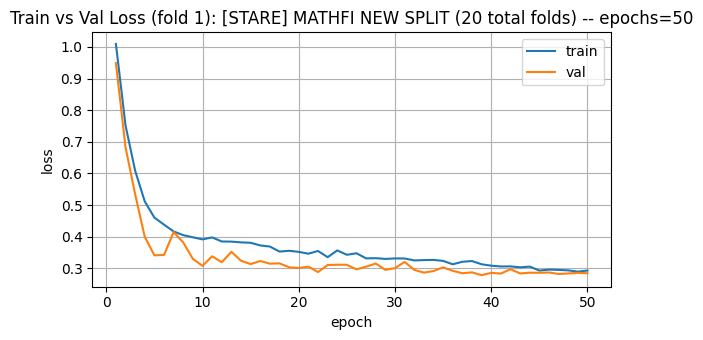

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold01.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.9048
Specificity    : 0.9730
clDice         : 0.8586
Accuracy       : 0.9684
Dice           : 0.7932
IoU            : 0.6573
Precision      : 0.7062
FPR            : 0.0270
FDR            : 0.2938
Dice_thin      : 0.4603
Dice_thick     : 0.6091
ROC_AUC        : 0.9909
PR_AUC         : 0.8955
-- Micro (pooled over all pixels) --
Sensitivity    : 0.9048
Specificity    : 0.9730
F1/Dice        : 0.7932
Accuracy       : 0.9684
IoU            : 0.6573
Precision      : 0.7062
FPR            : 0.0270
FDR            : 0.2938
ROC_AUC        : 0.9909
PR_AUC         : 0.8955


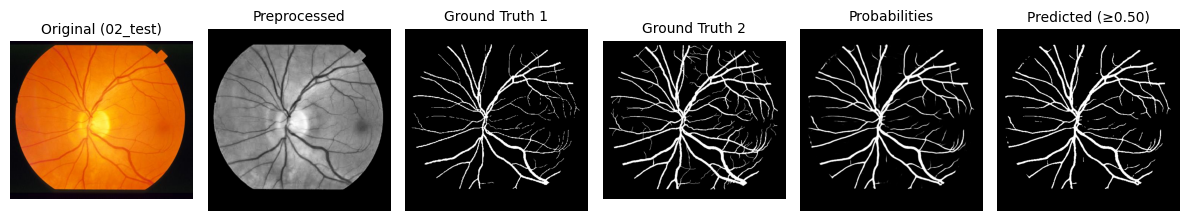

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold01.png ==

========== MATHFI STARE NEW SPLIT, Fold 3/20 ==========


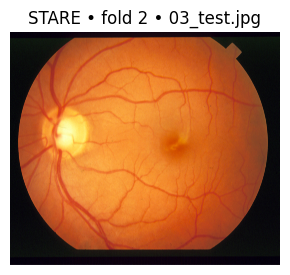

[F02 E001] train=1.0376 val=0.8759 lr=1.20e-04 time=29.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E002] train=0.7855 val=0.7283 lr=1.80e-04 time=30.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E003] train=0.6336 val=0.5922 lr=2.40e-04 time=29.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E004] train=0.5280 val=0.4836 lr=3.00e-04 time=30.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E005] train=0.4681 val=0.4152 lr=3.00e-04 time=29.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E006] train=0.4580 val=0.3433 lr=3.00e-04 time=30.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth
[F02 E007] train=0.4263 val=0.3736 lr=2.99e-04 time=29.9s
[F02 E008] train=0.4214 val=0.3482 lr=2.97e-04 time=29.7s
[F02 E009] train=0.4

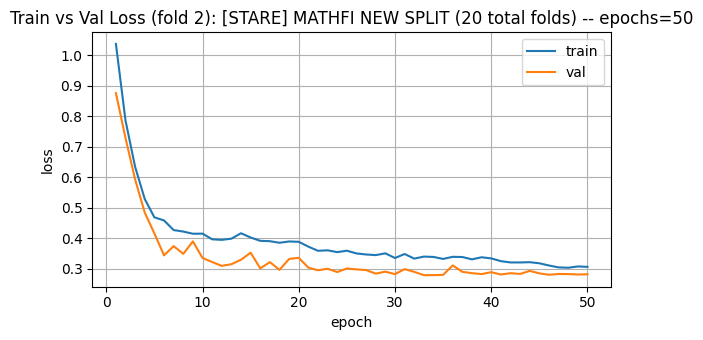

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold02.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8876
Specificity    : 0.9812
clDice         : 0.8481
Accuracy       : 0.9740
Dice           : 0.8403
IoU            : 0.7246
Precision      : 0.7977
FPR            : 0.0188
FDR            : 0.2023
Dice_thin      : 0.5023
Dice_thick     : 0.7008
ROC_AUC        : 0.9932
PR_AUC         : 0.9311
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8876
Specificity    : 0.9812
F1/Dice        : 0.8403
Accuracy       : 0.9740
IoU            : 0.7246
Precision      : 0.7977
FPR            : 0.0188
FDR            : 0.2023
ROC_AUC        : 0.9932
PR_AUC         : 0.9311


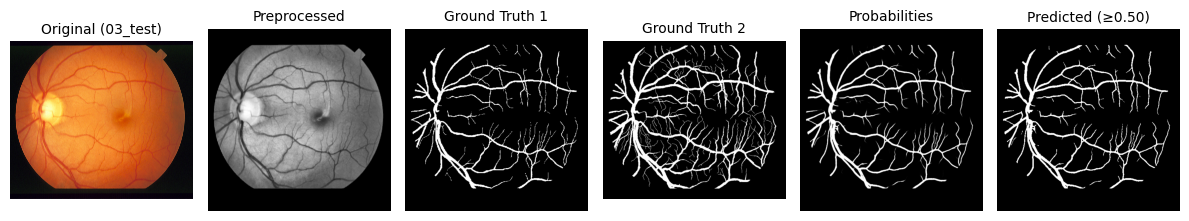

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold02.png ==

========== MATHFI STARE NEW SPLIT, Fold 4/20 ==========


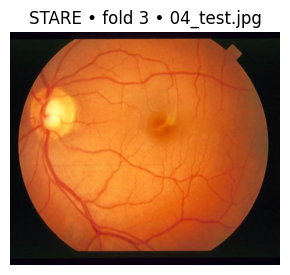

[F03 E001] train=1.1027 val=0.9459 lr=1.20e-04 time=30.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E002] train=0.8401 val=0.7991 lr=1.80e-04 time=30.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E003] train=0.6718 val=0.5565 lr=2.40e-04 time=31.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E004] train=0.5423 val=0.4832 lr=3.00e-04 time=30.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E005] train=0.4828 val=0.3715 lr=3.00e-04 time=30.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E006] train=0.4442 val=0.3858 lr=3.00e-04 time=30.6s
[F03 E007] train=0.4328 val=0.3235 lr=2.99e-04 time=30.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold03.pth
[F03 E008] train=0.4483 val=0.3320 lr=2.97e-04 time=30.6s
[F03 E009] train=0.4

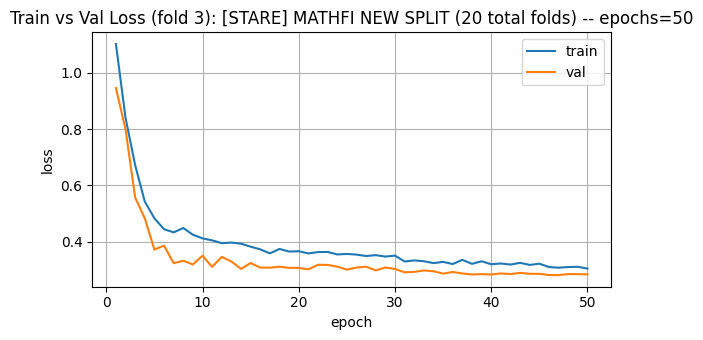

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold03.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8334
Specificity    : 0.9814
clDice         : 0.8391
Accuracy       : 0.9697
Dice           : 0.8127
IoU            : 0.6844
Precision      : 0.7929
FPR            : 0.0186
FDR            : 0.2071
Dice_thin      : 0.4631
Dice_thick     : 0.6639
ROC_AUC        : 0.9879
PR_AUC         : 0.8982
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8334
Specificity    : 0.9814
F1/Dice        : 0.8127
Accuracy       : 0.9697
IoU            : 0.6844
Precision      : 0.7929
FPR            : 0.0186
FDR            : 0.2071
ROC_AUC        : 0.9879
PR_AUC         : 0.8982


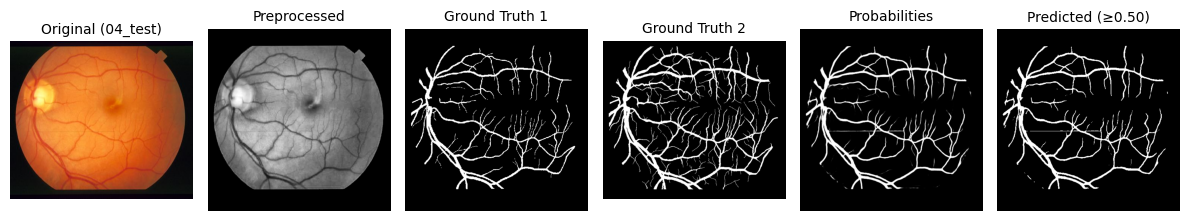

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold03.png ==

========== MATHFI STARE NEW SPLIT, Fold 5/20 ==========


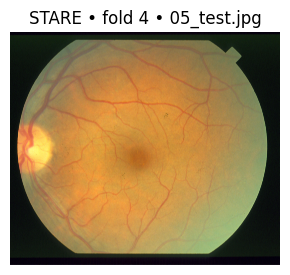

[F04 E001] train=1.1426 val=1.0305 lr=1.20e-04 time=31.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E002] train=0.8490 val=0.7644 lr=1.80e-04 time=31.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E003] train=0.6652 val=0.5887 lr=2.40e-04 time=31.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E004] train=0.5522 val=0.4486 lr=3.00e-04 time=31.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E005] train=0.4848 val=0.4119 lr=3.00e-04 time=31.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E006] train=0.4561 val=0.3438 lr=3.00e-04 time=31.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold04.pth
[F04 E007] train=0.4386 val=0.3106 lr=2.99e-04 time=31.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fol

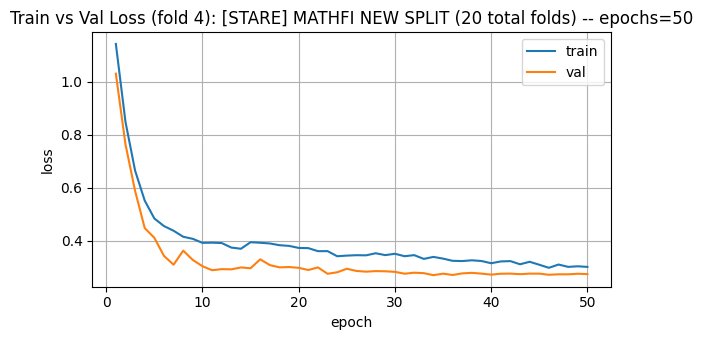

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold04.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8262
Specificity    : 0.9833
clDice         : 0.8320
Accuracy       : 0.9715
Dice           : 0.8128
IoU            : 0.6846
Precision      : 0.7998
FPR            : 0.0167
FDR            : 0.2002
Dice_thin      : 0.4925
Dice_thick     : 0.6636
ROC_AUC        : 0.9898
PR_AUC         : 0.8983
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8262
Specificity    : 0.9833
F1/Dice        : 0.8128
Accuracy       : 0.9715
IoU            : 0.6846
Precision      : 0.7998
FPR            : 0.0167
FDR            : 0.2002
ROC_AUC        : 0.9898
PR_AUC         : 0.8983


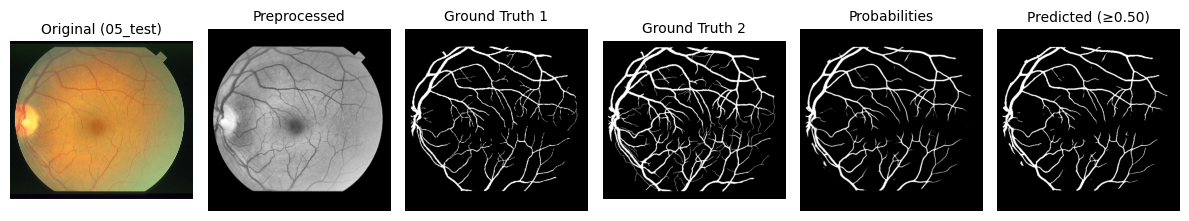

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold04.png ==

========== MATHFI STARE NEW SPLIT, Fold 6/20 ==========


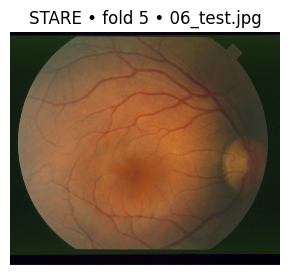

[F05 E001] train=1.0832 val=0.9438 lr=1.20e-04 time=32.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E002] train=0.7992 val=0.7223 lr=1.80e-04 time=32.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E003] train=0.6401 val=0.5467 lr=2.40e-04 time=32.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E004] train=0.5215 val=0.4471 lr=3.00e-04 time=32.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E005] train=0.4820 val=0.3790 lr=3.00e-04 time=32.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E006] train=0.4444 val=0.3989 lr=3.00e-04 time=32.5s
[F05 E007] train=0.4285 val=0.3419 lr=2.99e-04 time=33.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold05.pth
[F05 E008] train=0.4171 val=0.3513 lr=2.97e-04 time=32.3s
[F05 E009] train=0.4

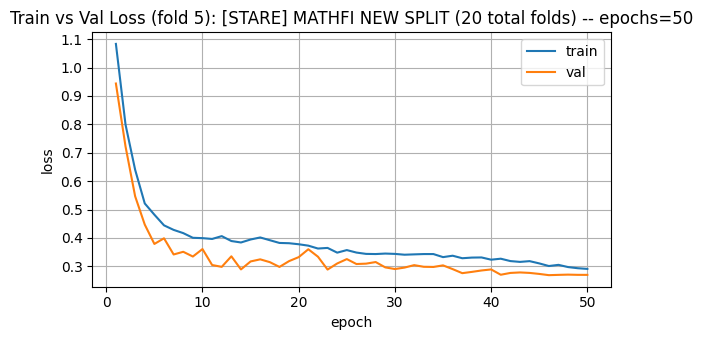

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold05.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7550
Specificity    : 0.9877
clDice         : 0.8631
Accuracy       : 0.9672
Dice           : 0.8023
IoU            : 0.6699
Precision      : 0.8559
FPR            : 0.0123
FDR            : 0.1441
Dice_thin      : 0.5025
Dice_thick     : 0.6676
ROC_AUC        : 0.9804
PR_AUC         : 0.8899
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7550
Specificity    : 0.9877
F1/Dice        : 0.8023
Accuracy       : 0.9672
IoU            : 0.6699
Precision      : 0.8559
FPR            : 0.0123
FDR            : 0.1441
ROC_AUC        : 0.9804
PR_AUC         : 0.8899


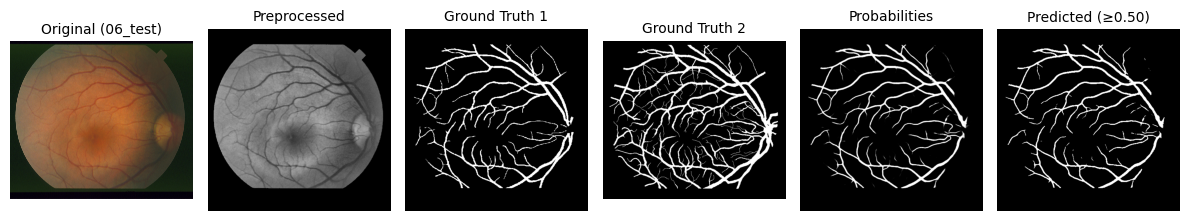

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold05.png ==

========== MATHFI STARE NEW SPLIT, Fold 7/20 ==========


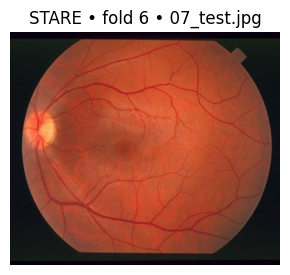

[F06 E001] train=1.0707 val=0.9484 lr=1.20e-04 time=32.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E002] train=0.8036 val=0.7507 lr=1.80e-04 time=33.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E003] train=0.6382 val=0.5188 lr=2.40e-04 time=32.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E004] train=0.5177 val=0.4493 lr=3.00e-04 time=32.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E005] train=0.4584 val=0.3469 lr=3.00e-04 time=33.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E006] train=0.4238 val=0.3625 lr=3.00e-04 time=32.8s
[F06 E007] train=0.4061 val=0.3172 lr=2.99e-04 time=33.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold06.pth
[F06 E008] train=0.3998 val=0.3028 lr=2.97e-04 time=33.4s
	CHECKPOINT SAVED: .

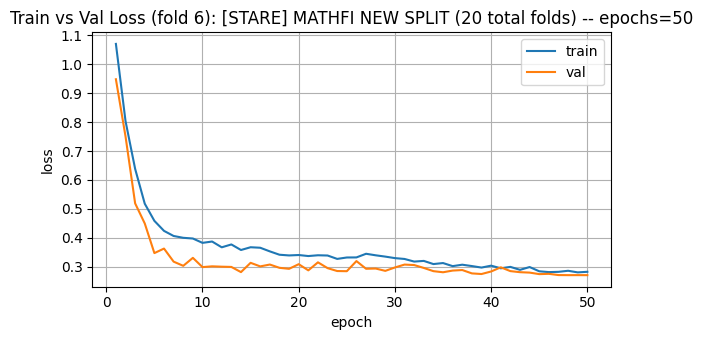

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold06.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.6823
Specificity    : 0.9869
clDice         : 0.7582
Accuracy       : 0.9632
Dice           : 0.7425
IoU            : 0.5905
Precision      : 0.8144
FPR            : 0.0131
FDR            : 0.1856
Dice_thin      : 0.3955
Dice_thick     : 0.5456
ROC_AUC        : 0.9783
PR_AUC         : 0.8385
-- Micro (pooled over all pixels) --
Sensitivity    : 0.6823
Specificity    : 0.9869
F1/Dice        : 0.7425
Accuracy       : 0.9632
IoU            : 0.5905
Precision      : 0.8144
FPR            : 0.0131
FDR            : 0.1856
ROC_AUC        : 0.9783
PR_AUC         : 0.8385


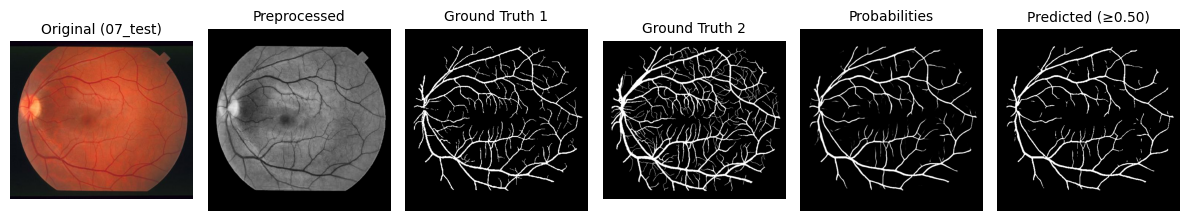

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold06.png ==

========== MATHFI STARE NEW SPLIT, Fold 8/20 ==========


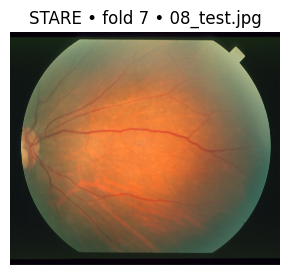

[F07 E001] train=1.0996 val=1.0331 lr=1.20e-04 time=32.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E002] train=0.8153 val=0.7033 lr=1.80e-04 time=33.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E003] train=0.6073 val=0.5220 lr=2.40e-04 time=33.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E004] train=0.5217 val=0.4061 lr=3.00e-04 time=32.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E005] train=0.4799 val=0.3735 lr=3.00e-04 time=32.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E006] train=0.4372 val=0.3810 lr=3.00e-04 time=32.4s
[F07 E007] train=0.4251 val=0.3403 lr=2.99e-04 time=32.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold07.pth
[F07 E008] train=0.4121 val=0.3190 lr=2.97e-04 time=33.4s
	CHECKPOINT SAVED: .

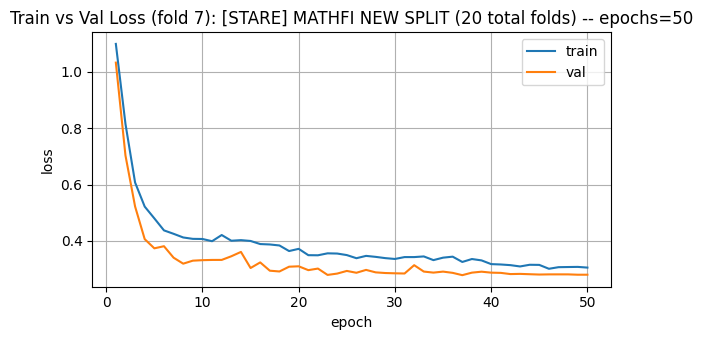

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold07.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8392
Specificity    : 0.9912
clDice         : 0.8700
Accuracy       : 0.9845
Dice           : 0.8255
IoU            : 0.7028
Precision      : 0.8122
FPR            : 0.0088
FDR            : 0.1878
Dice_thin      : 0.5625
Dice_thick     : 0.6871
ROC_AUC        : 0.9913
PR_AUC         : 0.9045
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8392
Specificity    : 0.9912
F1/Dice        : 0.8255
Accuracy       : 0.9845
IoU            : 0.7028
Precision      : 0.8122
FPR            : 0.0088
FDR            : 0.1878
ROC_AUC        : 0.9913
PR_AUC         : 0.9045


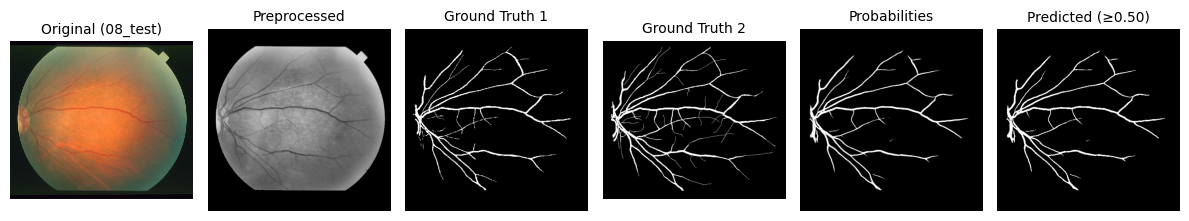

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold07.png ==

========== MATHFI STARE NEW SPLIT, Fold 9/20 ==========


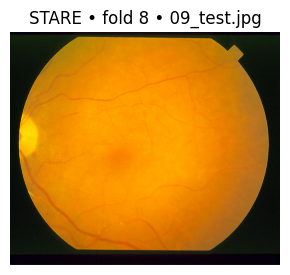

[F08 E001] train=0.9405 val=0.8013 lr=1.20e-04 time=33.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E002] train=0.7116 val=0.6621 lr=1.80e-04 time=33.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E003] train=0.5777 val=0.5364 lr=2.40e-04 time=34.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E004] train=0.5110 val=0.4105 lr=3.00e-04 time=34.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E005] train=0.4653 val=0.4170 lr=3.00e-04 time=33.7s
[F08 E006] train=0.4389 val=0.3866 lr=3.00e-04 time=33.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E007] train=0.4298 val=0.3227 lr=2.99e-04 time=33.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold08.pth
[F08 E008] train=0.4119 val=0.3655 lr=2.97e-04 time=33.5s
[F08 E009] train=0.4

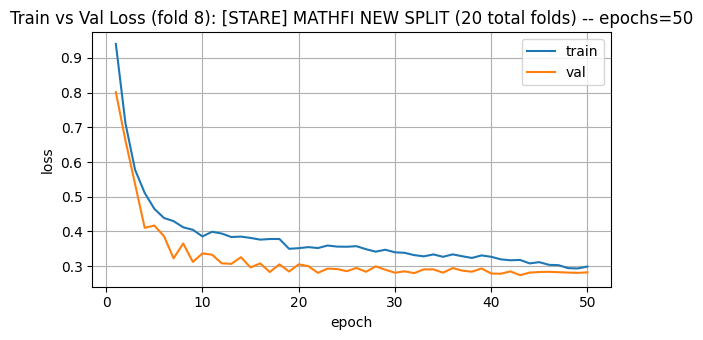

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold08.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.7898
Specificity    : 0.9910
clDice         : 0.8350
Accuracy       : 0.9834
Dice           : 0.7812
IoU            : 0.6410
Precision      : 0.7728
FPR            : 0.0090
FDR            : 0.2272
Dice_thin      : 0.5087
Dice_thick     : 0.6018
ROC_AUC        : 0.9929
PR_AUC         : 0.8726
-- Micro (pooled over all pixels) --
Sensitivity    : 0.7898
Specificity    : 0.9910
F1/Dice        : 0.7812
Accuracy       : 0.9834
IoU            : 0.6410
Precision      : 0.7728
FPR            : 0.0090
FDR            : 0.2272
ROC_AUC        : 0.9929
PR_AUC         : 0.8726


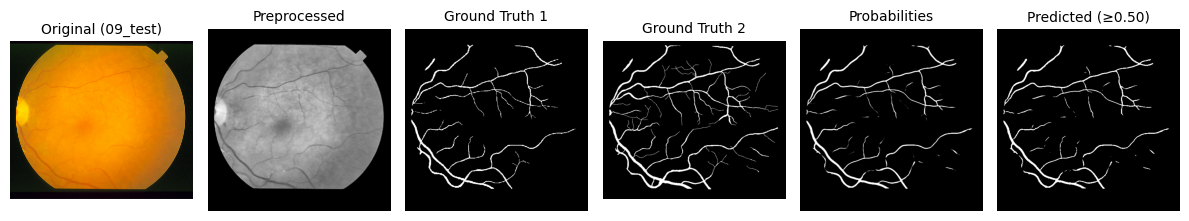

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold08.png ==

========== MATHFI STARE NEW SPLIT, Fold 10/20 ==========


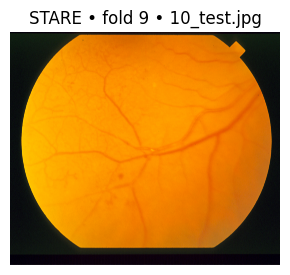

[F09 E001] train=1.0180 val=0.8973 lr=1.20e-04 time=34.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E002] train=0.7794 val=0.7626 lr=1.80e-04 time=34.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E003] train=0.6114 val=0.5631 lr=2.40e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E004] train=0.5196 val=0.4232 lr=3.00e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E005] train=0.4623 val=0.3635 lr=3.00e-04 time=34.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E006] train=0.4454 val=0.4094 lr=3.00e-04 time=34.2s
[F09 E007] train=0.4386 val=0.3561 lr=2.99e-04 time=34.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold09.pth
[F09 E008] train=0.4239 val=0.3123 lr=2.97e-04 time=33.9s
	CHECKPOINT SAVED: .

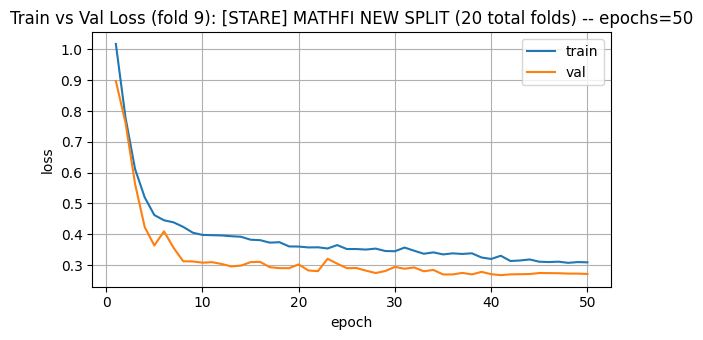

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold09.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8352
Specificity    : 0.9792
clDice         : 0.8486
Accuracy       : 0.9709
Dice           : 0.7679
IoU            : 0.6232
Precision      : 0.7107
FPR            : 0.0208
FDR            : 0.2893
Dice_thin      : 0.4218
Dice_thick     : 0.6180
ROC_AUC        : 0.9875
PR_AUC         : 0.8491
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8352
Specificity    : 0.9792
F1/Dice        : 0.7679
Accuracy       : 0.9709
IoU            : 0.6232
Precision      : 0.7107
FPR            : 0.0208
FDR            : 0.2893
ROC_AUC        : 0.9875
PR_AUC         : 0.8491


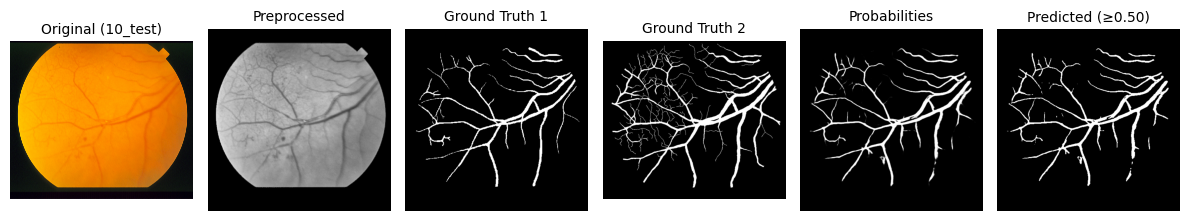

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold09.png ==

========== MATHFI STARE NEW SPLIT, Fold 11/20 ==========


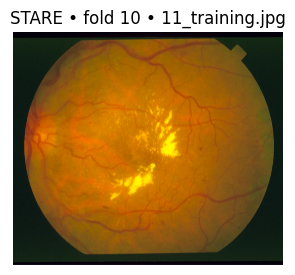

[F10 E001] train=1.1558 val=0.9832 lr=1.20e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E002] train=0.8659 val=0.7927 lr=1.80e-04 time=34.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E003] train=0.6839 val=0.5792 lr=2.40e-04 time=34.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E004] train=0.5645 val=0.4822 lr=3.00e-04 time=34.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E005] train=0.5138 val=0.4216 lr=3.00e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E006] train=0.4634 val=0.3752 lr=3.00e-04 time=34.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold10.pth
[F10 E007] train=0.4299 val=0.3345 lr=2.99e-04 time=34.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fol

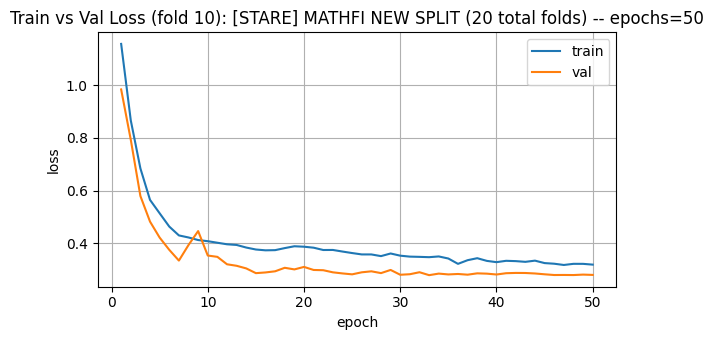

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold10.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8251
Specificity    : 0.9862
clDice         : 0.8518
Accuracy       : 0.9750
Dice           : 0.8202
IoU            : 0.6952
Precision      : 0.8154
FPR            : 0.0138
FDR            : 0.1846
Dice_thin      : 0.4988
Dice_thick     : 0.6684
ROC_AUC        : 0.9910
PR_AUC         : 0.9056
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8251
Specificity    : 0.9862
F1/Dice        : 0.8202
Accuracy       : 0.9750
IoU            : 0.6952
Precision      : 0.8154
FPR            : 0.0138
FDR            : 0.1846
ROC_AUC        : 0.9910
PR_AUC         : 0.9056


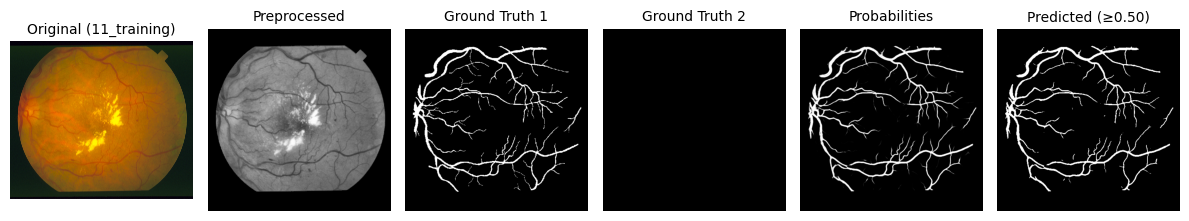

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold10.png ==

========== MATHFI STARE NEW SPLIT, Fold 12/20 ==========


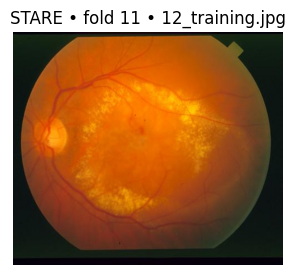

[F11 E001] train=1.1129 val=1.0032 lr=1.20e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E002] train=0.8513 val=0.7883 lr=1.80e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E003] train=0.6744 val=0.5767 lr=2.40e-04 time=34.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E004] train=0.5497 val=0.4924 lr=3.00e-04 time=34.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E005] train=0.4787 val=0.4368 lr=3.00e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E006] train=0.4452 val=0.3772 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold11.pth
[F11 E007] train=0.4267 val=0.3361 lr=2.99e-04 time=34.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fol

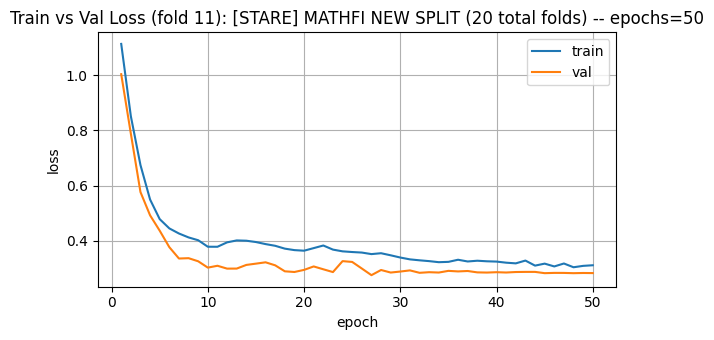

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold11.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.6087
Specificity    : 0.9885
clDice         : 0.6763
Accuracy       : 0.9665
Dice           : 0.6775
IoU            : 0.5123
Precision      : 0.7638
FPR            : 0.0115
FDR            : 0.2362
Dice_thin      : 0.2812
Dice_thick     : 0.5142
ROC_AUC        : 0.9613
PR_AUC         : 0.7513
-- Micro (pooled over all pixels) --
Sensitivity    : 0.6087
Specificity    : 0.9885
F1/Dice        : 0.6775
Accuracy       : 0.9665
IoU            : 0.5123
Precision      : 0.7638
FPR            : 0.0115
FDR            : 0.2362
ROC_AUC        : 0.9613
PR_AUC         : 0.7513


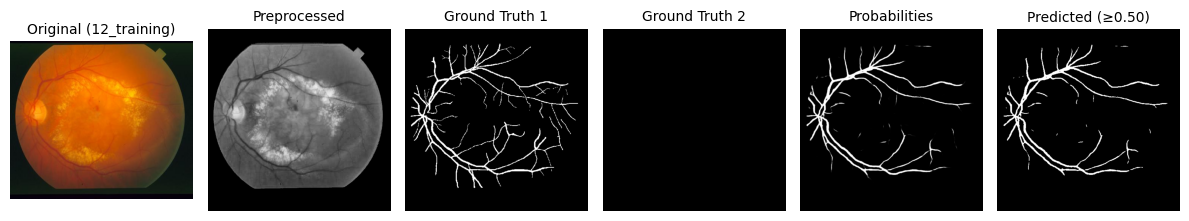

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold11.png ==

========== MATHFI STARE NEW SPLIT, Fold 13/20 ==========


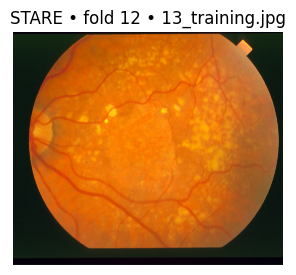

[F12 E001] train=1.1072 val=0.9951 lr=1.20e-04 time=34.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E002] train=0.8277 val=0.7758 lr=1.80e-04 time=34.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E003] train=0.6520 val=0.6077 lr=2.40e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E004] train=0.5413 val=0.4191 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E005] train=0.4664 val=0.3574 lr=3.00e-04 time=35.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E006] train=0.4415 val=0.3362 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold12.pth
[F12 E007] train=0.4277 val=0.3363 lr=2.99e-04 time=35.3s
[F12 E008] train=0.4091 val=0.3350 lr=2.97e-04 time=34.4s
	CHECKPOINT SAVED: .

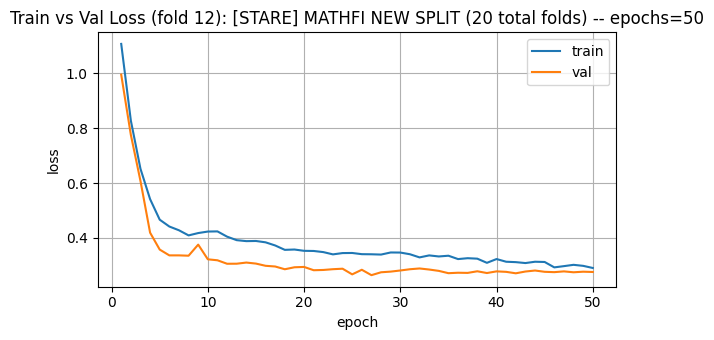

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold12.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8359
Specificity    : 0.9888
clDice         : 0.8295
Accuracy       : 0.9809
Dice           : 0.8188
IoU            : 0.6932
Precision      : 0.8025
FPR            : 0.0112
FDR            : 0.1975
Dice_thin      : 0.5282
Dice_thick     : 0.7017
ROC_AUC        : 0.9919
PR_AUC         : 0.9054
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8359
Specificity    : 0.9888
F1/Dice        : 0.8188
Accuracy       : 0.9809
IoU            : 0.6932
Precision      : 0.8025
FPR            : 0.0112
FDR            : 0.1975
ROC_AUC        : 0.9919
PR_AUC         : 0.9054


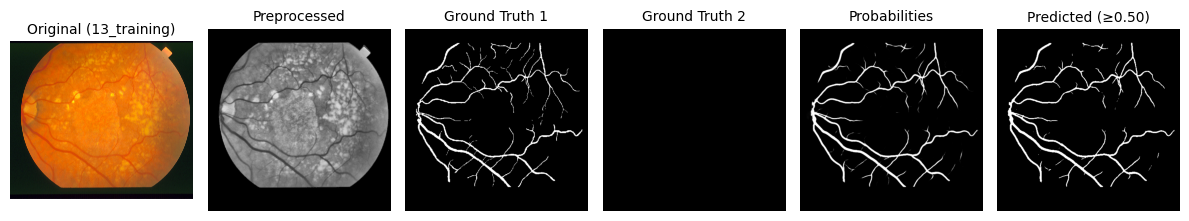

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold12.png ==

========== MATHFI STARE NEW SPLIT, Fold 14/20 ==========


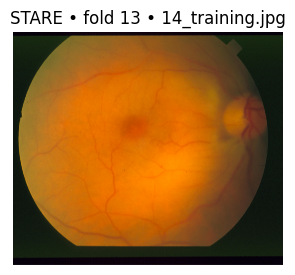

[F13 E001] train=1.1435 val=0.9826 lr=1.20e-04 time=35.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E002] train=0.8696 val=0.7750 lr=1.80e-04 time=35.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E003] train=0.6884 val=0.5665 lr=2.40e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E004] train=0.5507 val=0.4626 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E005] train=0.4817 val=0.4216 lr=3.00e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E006] train=0.4606 val=0.3281 lr=3.00e-04 time=34.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold13.pth
[F13 E007] train=0.4341 val=0.3285 lr=2.99e-04 time=35.7s
[F13 E008] train=0.4114 val=0.3030 lr=2.97e-04 time=34.8s
	CHECKPOINT SAVED: .

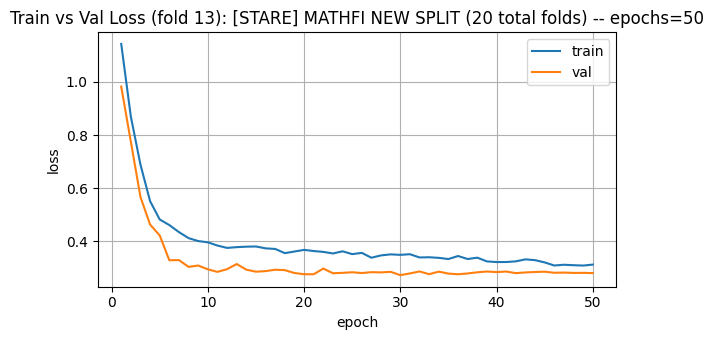

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold13.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.6402
Specificity    : 0.9880
clDice         : 0.8107
Accuracy       : 0.9657
Dice           : 0.7051
IoU            : 0.5446
Precision      : 0.7848
FPR            : 0.0120
FDR            : 0.2152
Dice_thin      : 0.4488
Dice_thick     : 0.5367
ROC_AUC        : 0.9694
PR_AUC         : 0.7677
-- Micro (pooled over all pixels) --
Sensitivity    : 0.6402
Specificity    : 0.9880
F1/Dice        : 0.7051
Accuracy       : 0.9657
IoU            : 0.5446
Precision      : 0.7848
FPR            : 0.0120
FDR            : 0.2152
ROC_AUC        : 0.9694
PR_AUC         : 0.7677


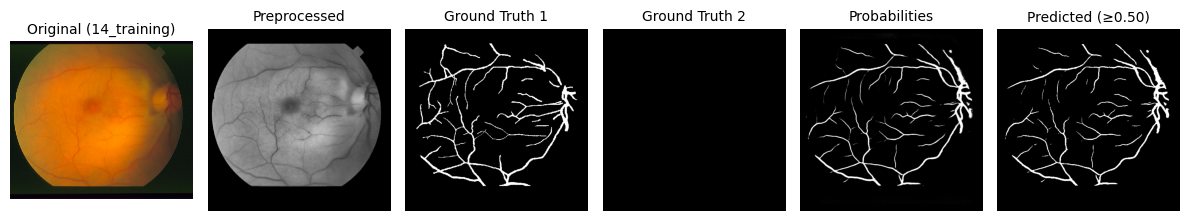

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold13.png ==

========== MATHFI STARE NEW SPLIT, Fold 15/20 ==========


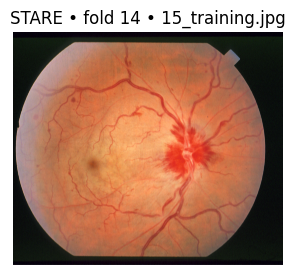

[F14 E001] train=1.0693 val=0.9306 lr=1.20e-04 time=35.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E002] train=0.8047 val=0.7208 lr=1.80e-04 time=35.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E003] train=0.6364 val=0.5435 lr=2.40e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E004] train=0.5166 val=0.4236 lr=3.00e-04 time=35.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E005] train=0.4697 val=0.3715 lr=3.00e-04 time=35.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E006] train=0.4350 val=0.3386 lr=3.00e-04 time=35.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold14.pth
[F14 E007] train=0.4176 val=0.3441 lr=2.99e-04 time=35.5s
[F14 E008] train=0.4353 val=0.3472 lr=2.97e-04 time=35.4s
[F14 E009] train=0.4

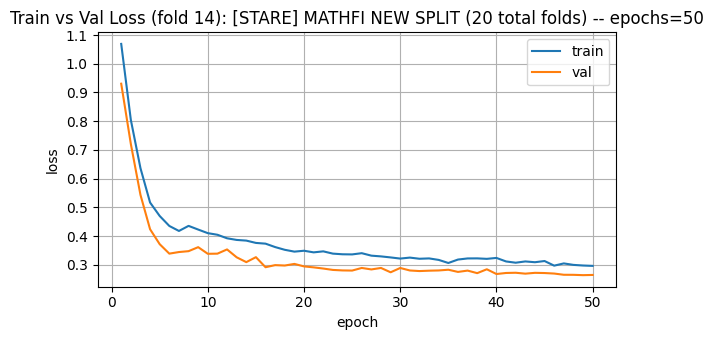

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold14.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.6886
Specificity    : 0.9894
clDice         : 0.8382
Accuracy       : 0.9658
Dice           : 0.7594
IoU            : 0.6121
Precision      : 0.8464
FPR            : 0.0106
FDR            : 0.1536
Dice_thin      : 0.4593
Dice_thick     : 0.5800
ROC_AUC        : 0.9861
PR_AUC         : 0.8640
-- Micro (pooled over all pixels) --
Sensitivity    : 0.6886
Specificity    : 0.9894
F1/Dice        : 0.7594
Accuracy       : 0.9658
IoU            : 0.6121
Precision      : 0.8464
FPR            : 0.0106
FDR            : 0.1536
ROC_AUC        : 0.9861
PR_AUC         : 0.8640


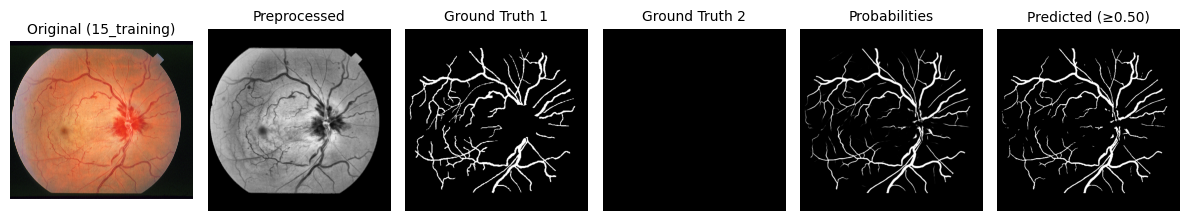

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold14.png ==

========== MATHFI STARE NEW SPLIT, Fold 16/20 ==========


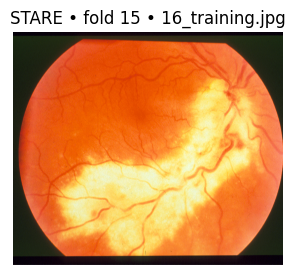

[F15 E001] train=1.1379 val=1.0203 lr=1.20e-04 time=35.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E002] train=0.8531 val=0.7789 lr=1.80e-04 time=35.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E003] train=0.6718 val=0.5760 lr=2.40e-04 time=34.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E004] train=0.5455 val=0.4218 lr=3.00e-04 time=35.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E005] train=0.4802 val=0.3628 lr=3.00e-04 time=35.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E006] train=0.4665 val=0.3691 lr=3.00e-04 time=35.4s
[F15 E007] train=0.4230 val=0.3232 lr=2.99e-04 time=35.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold15.pth
[F15 E008] train=0.4139 val=0.3217 lr=2.97e-04 time=35.6s
	CHECKPOINT SAVED: .

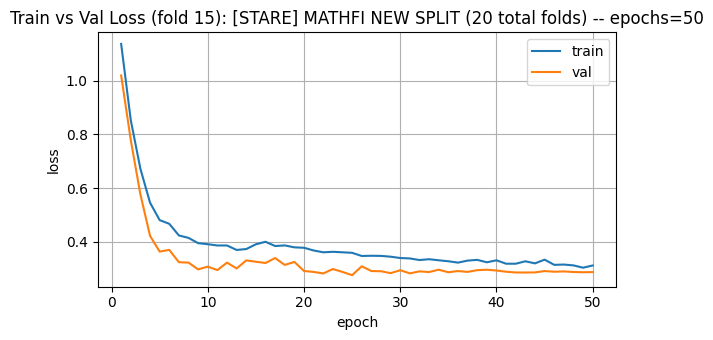

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold15.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8422
Specificity    : 0.9810
clDice         : 0.8296
Accuracy       : 0.9726
Dice           : 0.7877
IoU            : 0.6498
Precision      : 0.7399
FPR            : 0.0190
FDR            : 0.2601
Dice_thin      : 0.4803
Dice_thick     : 0.6338
ROC_AUC        : 0.9901
PR_AUC         : 0.8751
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8422
Specificity    : 0.9810
F1/Dice        : 0.7877
Accuracy       : 0.9726
IoU            : 0.6498
Precision      : 0.7399
FPR            : 0.0190
FDR            : 0.2601
ROC_AUC        : 0.9901
PR_AUC         : 0.8751


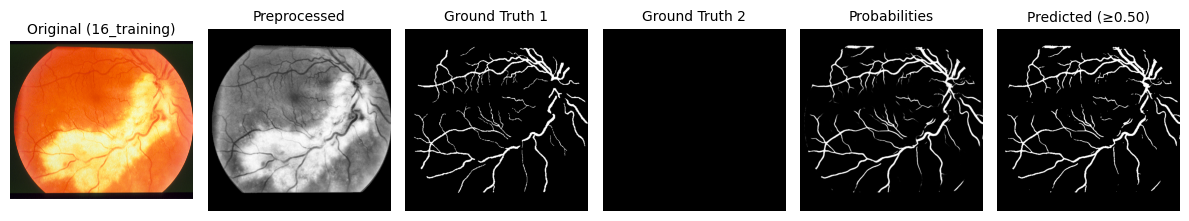

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold15.png ==

========== MATHFI STARE NEW SPLIT, Fold 17/20 ==========


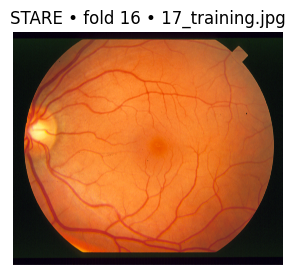

[F16 E001] train=1.1103 val=0.9364 lr=1.20e-04 time=35.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E002] train=0.8530 val=0.7682 lr=1.80e-04 time=35.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E003] train=0.6750 val=0.5806 lr=2.40e-04 time=36.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E004] train=0.5490 val=0.4685 lr=3.00e-04 time=35.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E005] train=0.4845 val=0.3876 lr=3.00e-04 time=36.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E006] train=0.4549 val=0.3382 lr=3.00e-04 time=36.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold16.pth
[F16 E007] train=0.4266 val=0.3290 lr=2.99e-04 time=35.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fol

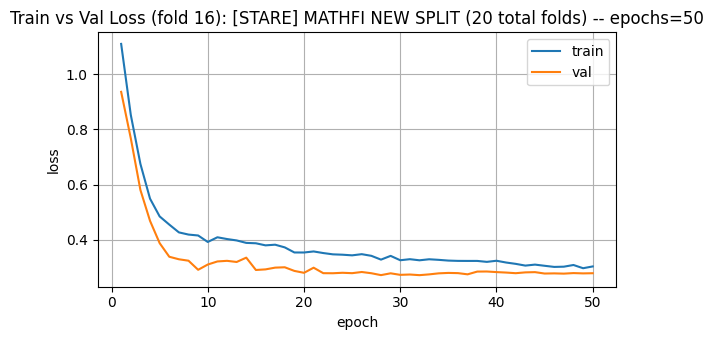

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold16.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.9196
Specificity    : 0.9780
clDice         : 0.8609
Accuracy       : 0.9739
Dice           : 0.8301
IoU            : 0.7096
Precision      : 0.7565
FPR            : 0.0220
FDR            : 0.2435
Dice_thin      : 0.5765
Dice_thick     : 0.6909
ROC_AUC        : 0.9939
PR_AUC         : 0.9336
-- Micro (pooled over all pixels) --
Sensitivity    : 0.9196
Specificity    : 0.9780
F1/Dice        : 0.8301
Accuracy       : 0.9739
IoU            : 0.7096
Precision      : 0.7565
FPR            : 0.0220
FDR            : 0.2435
ROC_AUC        : 0.9939
PR_AUC         : 0.9336


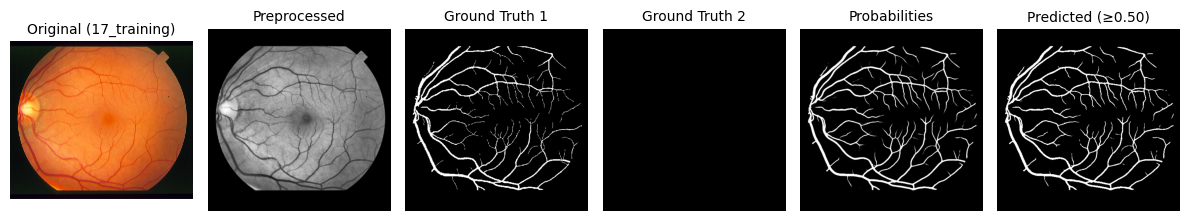

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold16.png ==

========== MATHFI STARE NEW SPLIT, Fold 18/20 ==========


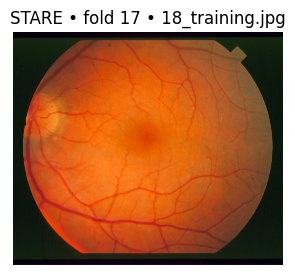

[F17 E001] train=1.0897 val=0.9440 lr=1.20e-04 time=36.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E002] train=0.8017 val=0.6872 lr=1.80e-04 time=36.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E003] train=0.6250 val=0.5112 lr=2.40e-04 time=36.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E004] train=0.5179 val=0.4242 lr=3.00e-04 time=36.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E005] train=0.4596 val=0.4173 lr=3.00e-04 time=36.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E006] train=0.4408 val=0.3695 lr=3.00e-04 time=36.1s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold17.pth
[F17 E007] train=0.4258 val=0.3544 lr=2.99e-04 time=36.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fol

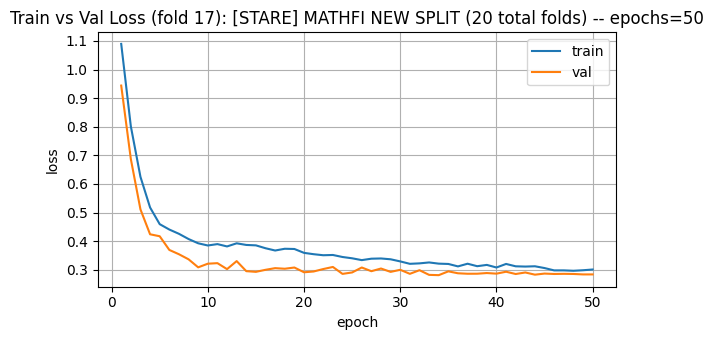

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold17.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8927
Specificity    : 0.9791
clDice         : 0.8451
Accuracy       : 0.9735
Dice           : 0.8139
IoU            : 0.6862
Precision      : 0.7479
FPR            : 0.0209
FDR            : 0.2521
Dice_thin      : 0.4931
Dice_thick     : 0.6425
ROC_AUC        : 0.9931
PR_AUC         : 0.9137
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8927
Specificity    : 0.9791
F1/Dice        : 0.8139
Accuracy       : 0.9735
IoU            : 0.6862
Precision      : 0.7479
FPR            : 0.0209
FDR            : 0.2521
ROC_AUC        : 0.9931
PR_AUC         : 0.9137


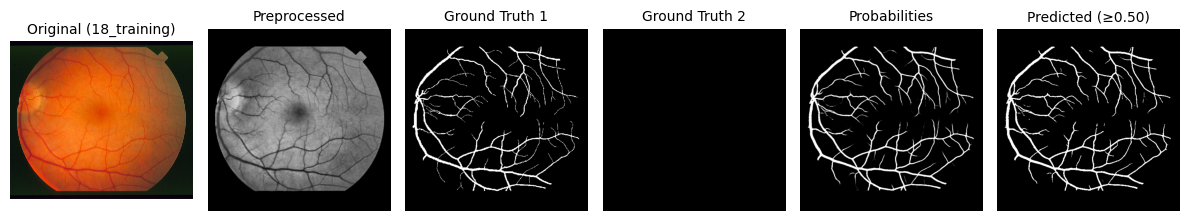

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold17.png ==

========== MATHFI STARE NEW SPLIT, Fold 19/20 ==========


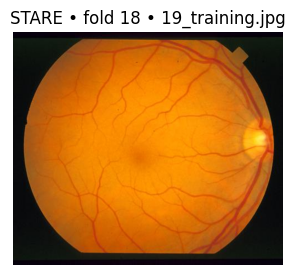

[F18 E001] train=1.1240 val=0.9918 lr=1.20e-04 time=36.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E002] train=0.8421 val=0.8309 lr=1.80e-04 time=36.6s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E003] train=0.6866 val=0.6268 lr=2.40e-04 time=37.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E004] train=0.5472 val=0.4647 lr=3.00e-04 time=36.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E005] train=0.4842 val=0.3504 lr=3.00e-04 time=36.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E006] train=0.4489 val=0.3814 lr=3.00e-04 time=36.5s
[F18 E007] train=0.4273 val=0.3475 lr=2.99e-04 time=36.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold18.pth
[F18 E008] train=0.4086 val=0.3080 lr=2.97e-04 time=33.5s
	CHECKPOINT SAVED: .

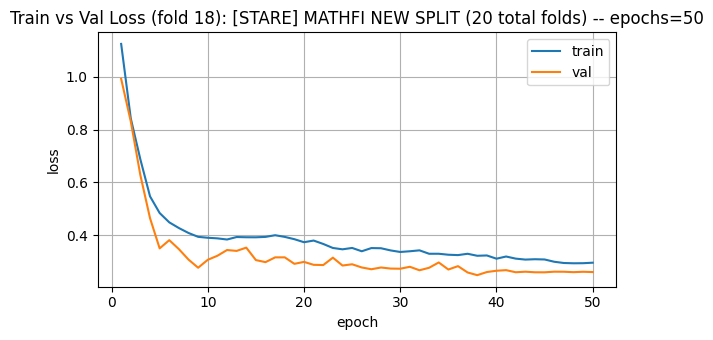

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold18.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8289
Specificity    : 0.9781
clDice         : 0.8181
Accuracy       : 0.9679
Dice           : 0.7791
IoU            : 0.6381
Precision      : 0.7349
FPR            : 0.0219
FDR            : 0.2651
Dice_thin      : 0.3996
Dice_thick     : 0.5925
ROC_AUC        : 0.9856
PR_AUC         : 0.8677
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8289
Specificity    : 0.9781
F1/Dice        : 0.7791
Accuracy       : 0.9679
IoU            : 0.6381
Precision      : 0.7349
FPR            : 0.0219
FDR            : 0.2651
ROC_AUC        : 0.9856
PR_AUC         : 0.8677


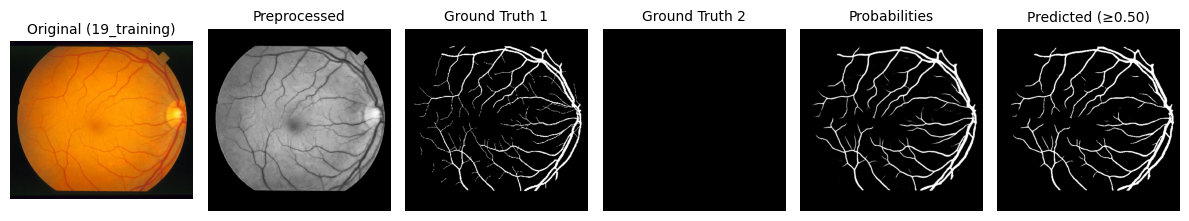

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold18.png ==

========== MATHFI STARE NEW SPLIT, Fold 20/20 ==========


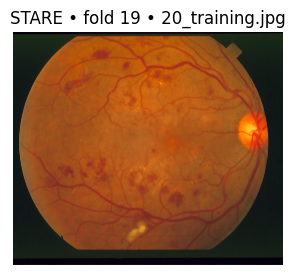

[F19 E001] train=1.0991 val=0.9444 lr=1.20e-04 time=47.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E002] train=0.8316 val=0.7541 lr=1.80e-04 time=48.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E003] train=0.6566 val=0.5847 lr=2.40e-04 time=46.9s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E004] train=0.5462 val=0.4161 lr=3.00e-04 time=46.4s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E005] train=0.4940 val=0.3781 lr=3.00e-04 time=47.0s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E006] train=0.4515 val=0.3254 lr=3.00e-04 time=47.2s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold19.pth
[F19 E007] train=0.4349 val=0.3245 lr=2.99e-04 time=35.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fol

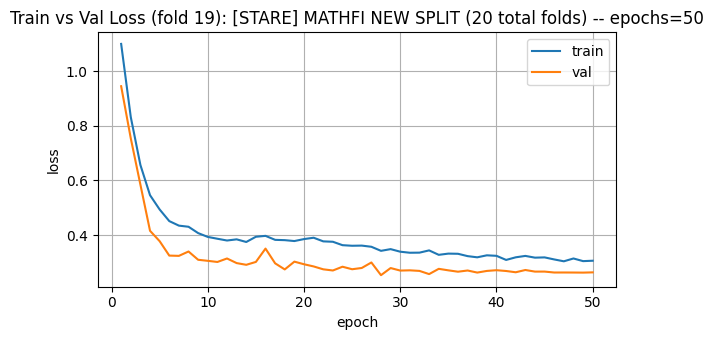

	 TRAIN vs VAL SAVED TO: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\TrainVsVal__fold19.png
=== Test Set Evaluation Metrics ===
-- Macro (per-image mean) --
Sensitivity    : 0.8406
Specificity    : 0.9805
clDice         : 0.8421
Accuracy       : 0.9708
Dice           : 0.7999
IoU            : 0.6665
Precision      : 0.7630
FPR            : 0.0195
FDR            : 0.2370
Dice_thin      : 0.4717
Dice_thick     : 0.6242
ROC_AUC        : 0.9892
PR_AUC         : 0.8900
-- Micro (pooled over all pixels) --
Sensitivity    : 0.8406
Specificity    : 0.9805
F1/Dice        : 0.7999
Accuracy       : 0.9708
IoU            : 0.6665
Precision      : 0.7630
FPR            : 0.0195
FDR            : 0.2370
ROC_AUC        : 0.9892
PR_AUC         : 0.8900


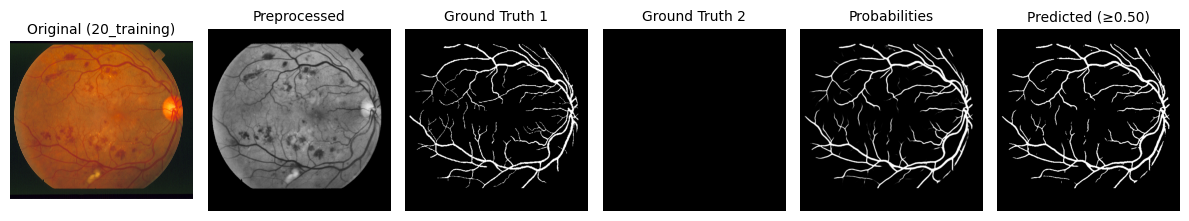

	== Visualization SAVED TO FILE: ..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\visuals\testSet__fold19.png ==

=== MATHFI STARE NEW SPLITS (20 folds) — mean ± std ===
SEN: 0.8056 ± 0.0869
SPE: 0.9835 ± 0.0052
CLDICE: 0.8261 ± 0.0454
ACC: 0.9718 ± 0.0058
Dice: 0.7871 ± 0.0416
IoU: 0.6507 ± 0.0546
AUC: 0.9866 ± 0.0084
AP: 0.8758 ± 0.0469


In [52]:
all_metrics, summary = run_stare_loo_experiment(
    model_name=MODEL_NAME,
    dataset=DATASET,
    V_MULT=V_MULT,
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=FOLD_ID,   #starts at any fold_id


    chckpnt_paths= [
        r"..\..\..\..\pth\MATHFI_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth"
         #"..\..\..\..\pth\{MODEL_NAME}_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
         #"..\..\..\..\pth\{MODEL_NAME}_STARE_NEWSPLIT\checkpoints\STARE_fold01.pth",
         #"..\..\..\..\pth\{MODEL_NAME}_STARE_NEWSPLIT\checkpoints\STARE_fold02.pth"

    ]
)
